# Backtesting — Modèles de Mortalité
**France Femmes 1950–2024 | PFA INSEA**

Ce notebook est uniquement dédié au backtesting et à la visualisation.
Toute la logique métier se trouve dans `src/models/`.

---
| Section | Modèle |
|---|---|
| 1 | Imports & données |
| 2 | Lee-Carter — fréquentiste |
| 3 | CBD |
| 4 | Renshaw-Haberman |
| 5 | Lee-Carter — Bayésien (Kalman Filter) |
| 6 | Pricing rente viagère |
| 7 | Comparaison finale |

## 1. Imports & données

In [3]:
import os, sys

# Chemin absolu vers la racine du projet
PROJECT_ROOT = r"C:\Users\PC-HP\Desktop\insea\Mortality Project"
# ex : r"C:\Users\PC-HP\Downloads\pfa_insea"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Root : {PROJECT_ROOT}")
print(f"src trouvé : {os.path.exists(os.path.join(PROJECT_ROOT, 'src'))}")

Root : C:\Users\PC-HP\Desktop\insea\Mortality Project
src trouvé : True


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from src.models.lee_carter         import fit_lee_carter
from src.models.life_expectancy    import compute_life_table
from src.models.cbd_model          import fit_cbd
from src.models.uncertainty        import bootstrap_e0_ci
from src.models.forecast_evaluation import rolling_backtest, compute_residual_std
from src.models.renshaw_haberman   import fit_renshaw_haberman, rolling_backtest_rh
from src.models.kalman_filter      import fit_kalman, rolling_backtest_bayesian
from src.models.pricing            import compute_annuity, annuity_var_cbd, price_all_models

os.makedirs('outputs', exist_ok=True)
print('Imports OK')

Imports OK


In [8]:
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
print(f"Data dir : {DATA_DIR}")
print(f"Fichiers trouvés : {os.listdir(DATA_DIR)}")

def load_data():
    df_d = pd.read_csv(os.path.join(DATA_DIR, "france_deaths_clean.csv"))
    df_p = pd.read_csv(os.path.join(DATA_DIR, "france_population_clean.csv"))
    d_l  = df_d.melt(id_vars=['Year','Age'], value_vars=['Male','Female'],
                     var_name='Sex', value_name='Deaths')
    p_l  = df_p.melt(id_vars=['Year','Age'], value_vars=['Male','Female'],
                     var_name='Sex', value_name='Population')
    df   = pd.merge(d_l, p_l, on=['Year','Age','Sex'])
    df['mx'] = df['Deaths'] / df['Population']
    return df

SEX      = 'Female'
df       = load_data()
df_model = df[(df['Year'] >= 1950) & (df['Age'] <= 90) & (df['Sex'] == SEX) & (df['mx'] > 0)].copy()
df_train = df_model[df_model['Year'] <= 2000].copy()
df_test  = df_model[df_model['Year'] >  2000].copy()

print(f'Train : {df_train["Year"].min()}–{df_train["Year"].max()}, {df_train["Age"].nunique()} âges')
print(f'Test  : {df_test["Year"].min()}–{df_test["Year"].max()},  {df_test["Age"].nunique()} âges')

Data dir : C:\Users\PC-HP\Desktop\insea\Mortality Project\data
Fichiers trouvés : ['france_deaths_clean.csv', 'france_population_clean.csv']
Train : 1950–2000, 91 âges
Test  : 2001–2023,  91 âges


## 2. Lee-Carter — Fréquentiste

In [9]:
ax, bx, kt_train = fit_lee_carter(df_train)
assert abs(kt_train.mean()) < 0.01
assert abs(bx.sum() - 1.0)  < 0.01
print(f'ax range : [{ax.min():.3f}, {ax.max():.3f}]')
print(f'kt range : [{kt_train.min():.3f}, {kt_train.max():.3f}]')

ax range : [-8.469, -1.531]
kt range : [-49.734, 56.831]


Residual std LC : 0.0975


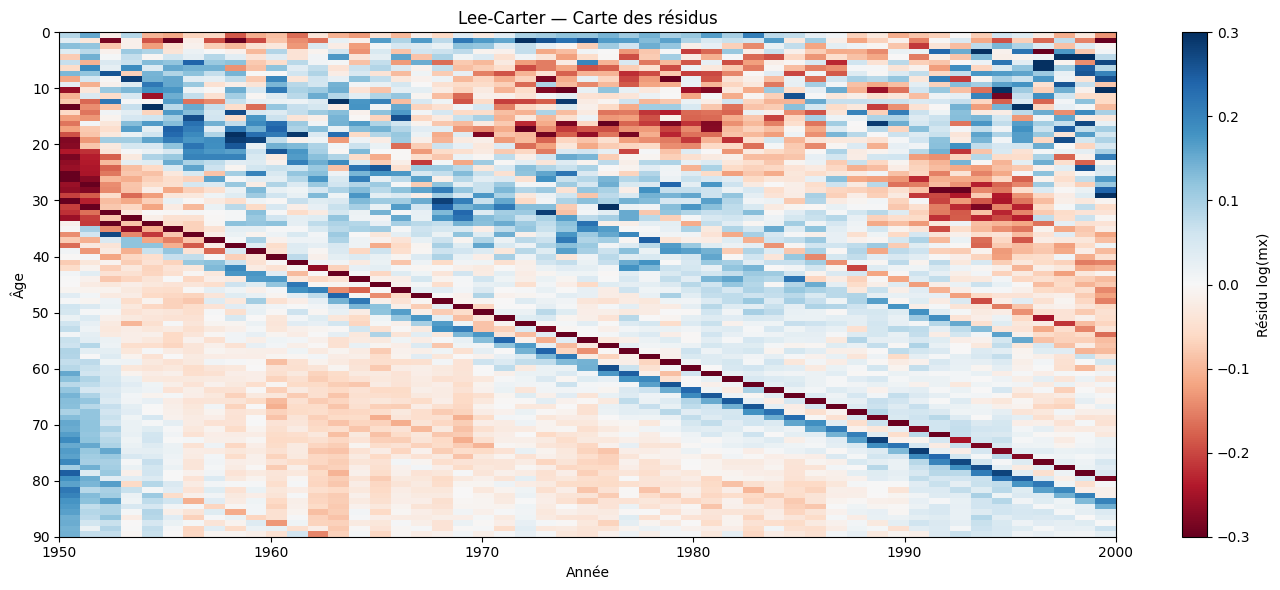

In [10]:
# ── Heatmap résidus ───────────────────────────────────────────────────────────
log_mx_fit      = pd.DataFrame({y: ax + bx * kt_train[y] for y in kt_train.index})
log_mx_actual   = np.log(df_train.pivot(index='Age', columns='Year', values='mx').clip(lower=1e-10))
residuals       = log_mx_fit - log_mx_actual
residual_std_lc = float(np.std((log_mx_fit.values - log_mx_actual.values).ravel()))
print(f'Residual std LC : {residual_std_lc:.4f}')

plt.figure(figsize=(14, 6))
plt.imshow(residuals.values, aspect='auto', cmap='RdBu', vmin=-0.3, vmax=0.3,
           extent=[kt_train.index[0], kt_train.index[-1], 90, 0])
plt.colorbar(label='Résidu log(mx)')
plt.xlabel('Année'); plt.ylabel('Âge')
plt.title('Lee-Carter — Carte des résidus')
plt.tight_layout()
plt.savefig('outputs/lc_residuals_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

LC  RMSE=0.4628  Bias=+0.1473  Coverage=91.3%


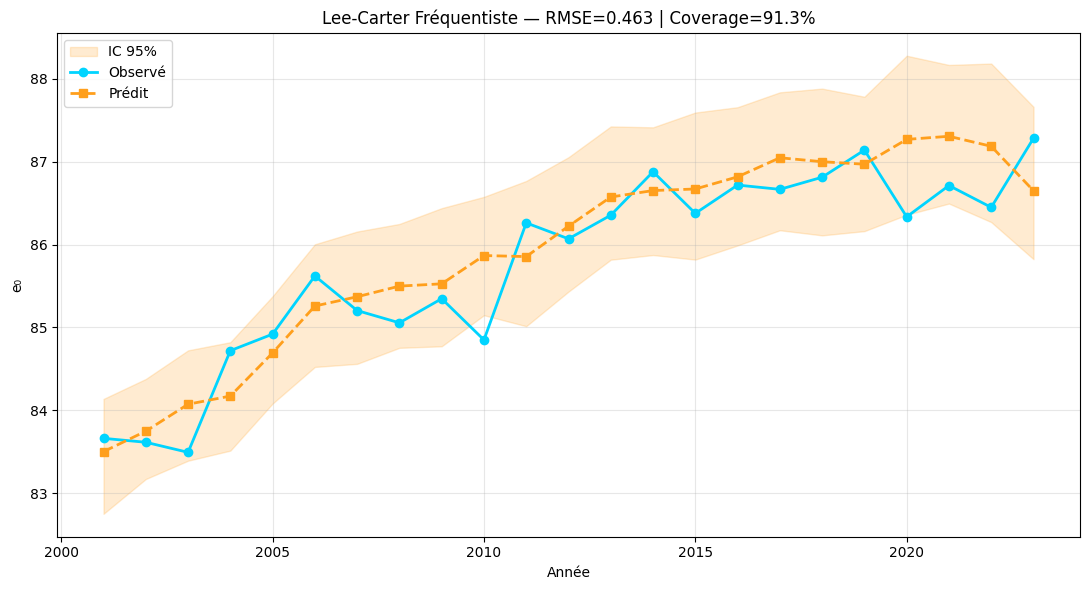

In [11]:
# ── Backtest LC fréquentiste ──────────────────────────────────────────────────
res_lc = rolling_backtest(ax, bx, kt_train, df_train, df_test, n_boot=300)

print(f'LC  RMSE={res_lc["rmse"]:.4f}  Bias={res_lc["bias"]:+.4f}  Coverage={res_lc["coverage"]:.1%}')

fig, a = plt.subplots(figsize=(11, 6))
a.fill_between(res_lc['years'], res_lc['e0_lower'], res_lc['e0_upper'], alpha=0.2, color='#ff9f1c', label='IC 95%')
a.plot(res_lc['years'], res_lc['e0_obs'],  'o-',  color='#00d4ff', lw=2, label='Observé')
a.plot(res_lc['years'], res_lc['e0_pred'], 's--', color='#ff9f1c', lw=2, label='Prédit')
a.set_title(f'Lee-Carter Fréquentiste — RMSE={res_lc["rmse"]:.3f} | Coverage={res_lc["coverage"]:.1%}', fontsize=12)
a.set_xlabel('Année'); a.set_ylabel('e₀'); a.legend(); a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/lc_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. CBD

CBD age range : 50–85  |  xbar=67.5
CBD residual std (logit qx) : 0.1342


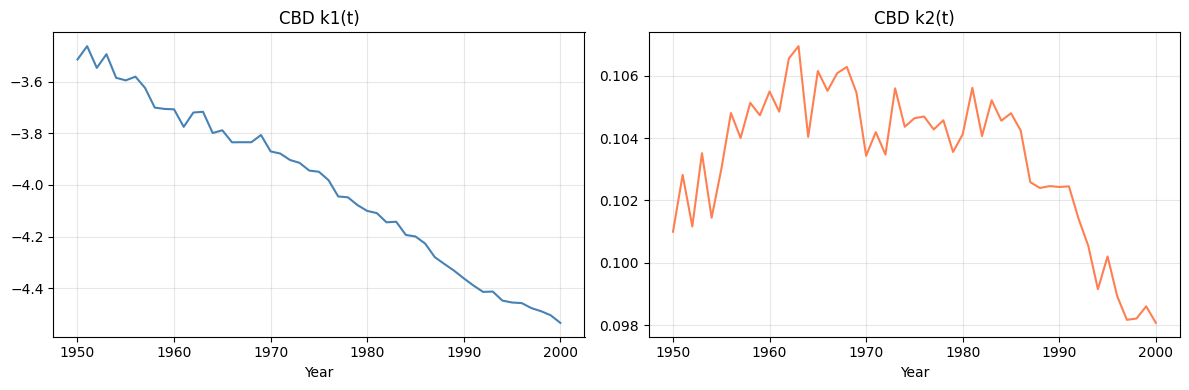

In [12]:
import pmdarima as pm

k1_train, k2_train, xbar = fit_cbd(df_train, age_min=50, age_max=85)

df_train_cbd = df_train[(df_train['Age'] >= 50) & (df_train['Age'] <= 85)].copy()
df_train_cbd['qx']       = df_train_cbd['mx'] / (1 + 0.5 * df_train_cbd['mx'])
df_train_cbd['qx']       = df_train_cbd['qx'].clip(1e-6, 1-1e-6)
df_train_cbd['logit_qx'] = np.log(df_train_cbd['qx'] / (1 - df_train_cbd['qx']))
df_pivot_cbd = df_train_cbd.pivot(index='Age', columns='Year', values='logit_qx')
ages_cbd     = df_pivot_cbd.index.values.astype(float)
logit_fit    = pd.DataFrame({y: k1_train[y] + k2_train[y]*(ages_cbd-xbar) for y in k1_train.index}, index=ages_cbd)
cbd_residual_std = float(np.std((logit_fit.values - df_pivot_cbd.values).ravel()))

print(f'CBD age range : {int(ages_cbd[0])}–{int(ages_cbd[-1])}  |  xbar={xbar:.1f}')
print(f'CBD residual std (logit qx) : {cbd_residual_std:.4f}')

# k1/k2 plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
k1_train.plot(ax=ax1, color='steelblue'); ax1.set_title('CBD k1(t)'); ax1.grid(alpha=0.3)
k2_train.plot(ax=ax2, color='coral');    ax2.set_title('CBD k2(t)'); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/cbd_k1_k2.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Backtest CBD ──────────────────────────────────────────────────────────────
def full_e0_from_cbd(k1_val, k2_val, xbar, ages_cbd, df_young_ext):
    logit_qx = k1_val + k2_val * (ages_cbd - xbar)
    qx_old   = (np.exp(logit_qx) / (1+np.exp(logit_qx))).clip(1e-6, 1-1e-6)
    mx_old   = (qx_old / (1-0.5*qx_old)).clip(min=1e-10)
    df_full  = pd.concat([df_young_ext,
                           pd.DataFrame({'Age': ages_cbd.astype(int), 'mx': mx_old})],
                          ignore_index=True).sort_values('Age').reset_index(drop=True)
    return compute_life_table(df_full).iloc[0]['ex']

k1_all = k1_train.copy(); k2_all = k2_train.copy()
e0_obs_cbd, e0_pred_cbd, e0_lower_cbd, e0_upper_cbd = [], [], [], []
years_test = sorted(df_test['Year'].unique())

for i, year in enumerate(years_test):
    print(f'  [{i+1}/{len(years_test)}] {year}...', end='\r')
    df_young = df_test[(df_test['Year']==year)&(df_test['Age']<=49)][['Age','mx']].reset_index(drop=True)
    df_tail  = df_test[(df_test['Year']==year)&(df_test['Age']>=86)&(df_test['Age']<=90)][['Age','mx']].reset_index(drop=True)
    df_old   = df_test[(df_test['Year']==year)&(df_test['Age']>=50)&(df_test['Age']<=85)][['Age','mx']].reset_index(drop=True)
    df_ext   = pd.concat([df_young, df_tail], ignore_index=True)

    m1 = pm.auto_arima(k1_all.values, seasonal=False, stepwise=True, suppress_warnings=True, error_action='ignore')
    m2 = pm.auto_arima(k2_all.values, seasonal=False, stepwise=True, suppress_warnings=True, error_action='ignore')
    fc1, ci1 = m1.predict(n_periods=1, return_conf_int=True, alpha=0.05)
    fc2, ci2 = m2.predict(n_periods=1, return_conf_int=True, alpha=0.05)
    k1_pt = float(fc1[0]); k2_pt = float(fc2[0])
    k1_std = (float(ci1[0,1])-float(ci1[0,0]))/(2*1.96)
    k2_std = (float(ci2[0,1])-float(ci2[0,0]))/(2*1.96)

    df_obs = pd.concat([df_young,df_old,df_tail],ignore_index=True).sort_values('Age').reset_index(drop=True)
    e0_obs_cbd.append(compute_life_table(df_obs).iloc[0]['ex'])
    e0_pred_cbd.append(full_e0_from_cbd(k1_pt, k2_pt, xbar, ages_cbd, df_ext))

    boot = []
    for _ in range(200):
        logit_s = np.random.normal(k1_pt,k1_std)+np.random.normal(k2_pt,k2_std)*(ages_cbd-xbar)+np.random.normal(0,cbd_residual_std,len(ages_cbd))
        qx_s = (np.exp(logit_s)/(1+np.exp(logit_s))).clip(1e-6,1-1e-6)
        mx_s = (qx_s/(1-0.5*qx_s)).clip(min=1e-10)
        df_s = pd.concat([df_ext, pd.DataFrame({'Age':ages_cbd.astype(int),'mx':mx_s})],ignore_index=True).sort_values('Age').reset_index(drop=True)
        boot.append(compute_life_table(df_s).iloc[0]['ex'])
    e0_lower_cbd.append(np.percentile(boot,2.5)); e0_upper_cbd.append(np.percentile(boot,97.5))

    df_yr = df_test[(df_test['Year']==year)&(df_test['Age']>=50)&(df_test['Age']<=85)][['Age','mx']].reset_index(drop=True)
    df_yr['logit_qx'] = np.log((df_yr['mx']/(1+0.5*df_yr['mx'])).clip(1e-6,1-1e-6))
    qx_yr = (df_yr['mx'] / (1 + 0.5 * df_yr['mx'])).clip(lower=1e-6, upper=1-1e-6)
    df_yr['logit_qx'] = np.log(qx_yr / (1 - qx_yr))
    X = np.column_stack([np.ones(len(ages_cbd)), ages_cbd-xbar])
    c = np.linalg.lstsq(X, df_yr['logit_qx'].values, rcond=None)[0]
    k1_all = pd.concat([k1_all, pd.Series([c[0]], index=[year])])
    k2_all = pd.concat([k2_all, pd.Series([c[1]], index=[year])])

e0_obs_cbd=np.array(e0_obs_cbd); e0_pred_cbd=np.array(e0_pred_cbd)
e0_lower_cbd=np.array(e0_lower_cbd); e0_upper_cbd=np.array(e0_upper_cbd)
rmse_cbd=float(np.sqrt(np.mean((e0_pred_cbd-e0_obs_cbd)**2)))
bias_cbd=float(np.mean(e0_pred_cbd-e0_obs_cbd))
coverage_cbd=float(np.mean((e0_obs_cbd>=e0_lower_cbd)&(e0_obs_cbd<=e0_upper_cbd)))
print(f'\nCBD RMSE={rmse_cbd:.4f}  Bias={bias_cbd:+.4f}  Coverage={coverage_cbd:.1%}')

  [23/23] 2023...
CBD RMSE=0.2200  Bias=+0.1282  Coverage=95.7%


## 4. Renshaw-Haberman

In [16]:
rh_params = fit_renshaw_haberman(df_train)
print(f'RH residual std après γc : {rh_params["residual_std"]:.4f}')
print(f'LC residual std sans  γc : {rh_params["lc_residual_std"]:.4f}')
print(f'Nb cohortes γc           : {len(rh_params["gamma_c"])}')

RH residual std après γc : 0.0748
LC residual std sans  γc : 0.0975
Nb cohortes γc           : 133


In [17]:
res_rh = rolling_backtest_rh(rh_params, df_test, n_boot=200)
print(f'RH  RMSE={res_rh["rmse"]:.4f}  Bias={res_rh["bias"]:+.4f}  Coverage={res_rh["coverage"]:.1%}')

RH  RMSE=0.3786  Bias=+0.0526  Coverage=91.3%


## 5. Lee-Carter — Bayésien (Kalman Filter)

In [18]:
kf_fit = fit_kalman(ax, bx, kt_train, df_train)
print(f'σ_process      : {kf_fit["sigma_proc"]:.4f}')
print(f'σ_obs (brut)   : {kf_fit["sigma_obs_raw"]:.4f}')
print(f'σ_obs (calibré): {kf_fit["sigma_obs_cal"]:.4f}')
print(f'drift          : {kf_fit["drift"]:.4f}')
print(f'residual std   : {kf_fit["residual_std"]:.4f}')

σ_process      : 1.5482
σ_obs (brut)   : 1.3528
σ_obs (calibré): 2.7056
drift          : -2.1177
residual std   : 0.0975


LC Bayésien  RMSE=0.4773  Bias=+0.1936  Coverage=95.7%


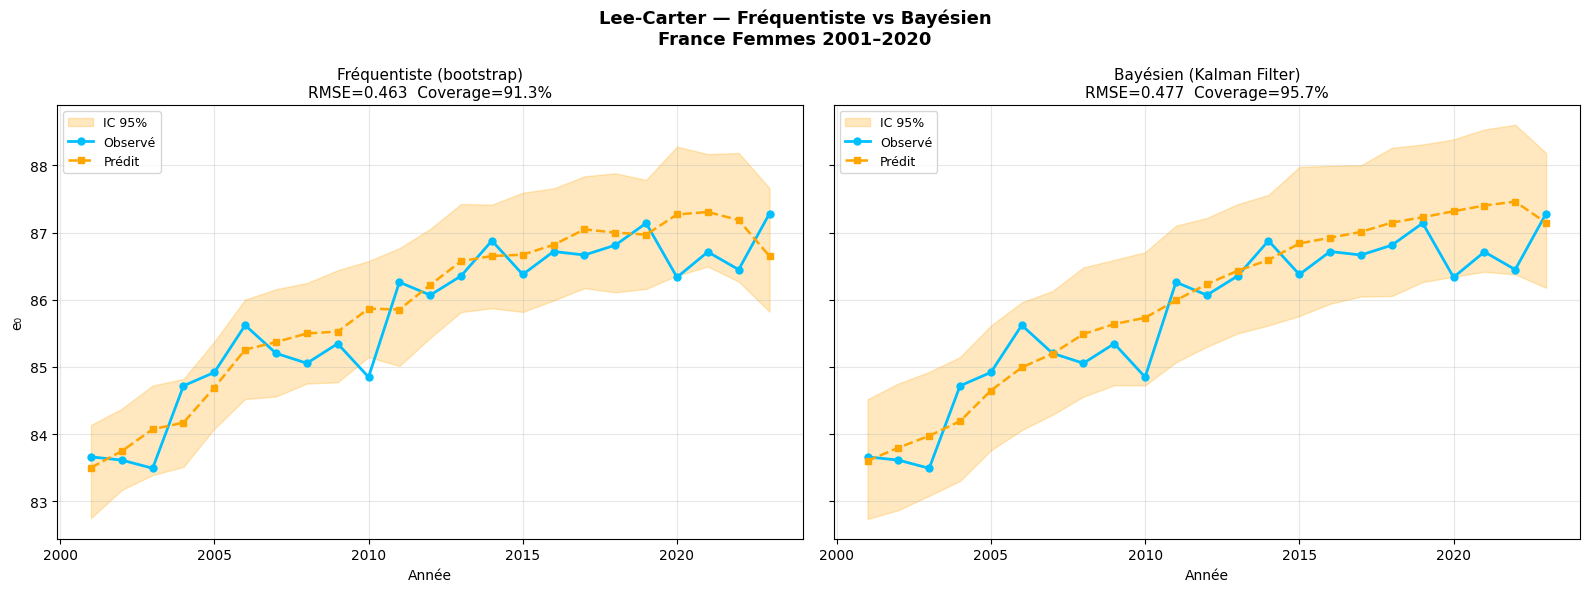

In [19]:
res_bay = rolling_backtest_bayesian(ax, bx, kt_train, kf_fit, df_test, n_mc=800)
print(f'LC Bayésien  RMSE={res_bay["rmse"]:.4f}  Bias={res_bay["bias"]:+.4f}  Coverage={res_bay["coverage"]:.1%}')

# Plot fréquentiste vs bayésien
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Lee-Carter — Fréquentiste vs Bayésien\nFrance Femmes 2001–2020', fontsize=13, fontweight='bold')
for ax_i, (title, res) in enumerate([('Fréquentiste (bootstrap)', res_lc), ('Bayésien (Kalman Filter)', res_bay)]):
    a = axes[ax_i]
    a.fill_between(res['years'], res['e0_lower'], res['e0_upper'], alpha=0.25, color='orange', label='IC 95%')
    a.plot(res['years'], res['e0_obs'],  'o-',  color='#00BFFF', lw=2,   label='Observé',  markersize=5)
    a.plot(res['years'], res['e0_pred'], 's--', color='orange',  lw=1.8, label='Prédit',   markersize=4)
    a.set_title(f'{title}\nRMSE={res["rmse"]:.3f}  Coverage={res["coverage"]:.1%}', fontsize=11)
    a.set_xlabel('Année'); a.legend(fontsize=9); a.grid(alpha=0.3)
    if ax_i == 0: a.set_ylabel('e₀')
plt.tight_layout()
plt.savefig('outputs/lc_frequentist_vs_bayesian.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Pricing rente viagère äx

In [20]:
TAUX_TECH  = 0.02
AGE_RENTE  = 65
CAPITAL    = 100_000
PROJ_YEAR  = 2025
N_FORECAST = int(PROJ_YEAR - int(rh_params['years_arr'][-1]))

import pmdarima as pm

# ── Tables projetées 2025 ────────────────────────────────────────────────────
# Lee-Carter
kt_2025  = float(pm.auto_arima(kt_train.values, seasonal=False, stepwise=True,
                 suppress_warnings=True, error_action='ignore').predict(n_periods=N_FORECAST)[-1])
mx_lc_25 = np.exp(ax.values + bx.values * kt_2025).clip(min=1e-10)
df_lc_25 = pd.DataFrame({'Age': ax.index.tolist(), 'mx': mx_lc_25})

# CBD
k1_25   = float(pm.auto_arima(k1_train.values, seasonal=False, stepwise=True,
                suppress_warnings=True, error_action='ignore').predict(n_periods=N_FORECAST)[-1])
k2_25   = float(pm.auto_arima(k2_train.values, seasonal=False, stepwise=True,
                suppress_warnings=True, error_action='ignore').predict(n_periods=N_FORECAST)[-1])
qx_c    = (np.exp(k1_25+k2_25*(ages_cbd-xbar))/(1+np.exp(k1_25+k2_25*(ages_cbd-xbar)))).clip(1e-6,1-1e-6)
mx_c    = (qx_c/(1-0.5*qx_c)).clip(min=1e-10)
df_cbd_25 = df_lc_25.copy()
for i, age in enumerate(ages_cbd.astype(int)):
    df_cbd_25.loc[df_cbd_25['Age']==age, 'mx'] = mx_c[i]

# Renshaw-Haberman
gamma_s  = pd.Series(rh_params['gamma_c']).sort_index()
from src.models.renshaw_haberman import get_gamma, predict_rh
df_rh_25 = predict_rh(rh_params, kt_2025, PROJ_YEAR, gamma_s)

# ── Pricing ──────────────────────────────────────────────────────────────────
models_mx = {'Lee-Carter': df_lc_25, 'CBD': df_cbd_25, 'Renshaw-Haberman': df_rh_25}
pricing_df = price_all_models(models_mx, AGE_RENTE, TAUX_TECH, CAPITAL)
print(f'Projection {PROJ_YEAR} | Femme {AGE_RENTE} ans | i={TAUX_TECH:.0%} | Capital {CAPITAL:,}€\n')
print(pricing_df.to_string())

Projection 2025 | Femme 65 ans | i=2% | Capital 100,000€

                       äx  Prime (€/an)
Modèle                                 
Lee-Carter        17.9937          5558
CBD               17.9687          5565
Renshaw-Haberman  18.0365          5544


In [21]:
# ── VaR longévité CBD ────────────────────────────────────────────────────────
var_result = annuity_var_cbd(
    k1_train, k2_train, ages_cbd, xbar, cbd_residual_std,
    df_lc_base=df_lc_25, age_x=AGE_RENTE, taux=TAUX_TECH,
    n_forecast=N_FORECAST, capital=CAPITAL, n_boot=1000
)
print(f'äx central          : {var_result["ax_central"]:.4f}')
print(f'äx P5/P95           : [{var_result["ax_p5"]:.4f}, {var_result["ax_p95"]:.4f}]')
print(f'Prime centrale      : {var_result["prime_central"]:,.0f} €/an')
print(f'Prime P5 (risque ↑) : {var_result["prime_p5"]:,.0f} €/an')
print(f'Prime P95           : {var_result["prime_p95"]:,.0f} €/an')
print(f'Risque de longévité : {var_result["longevity_risk"]:.4f}')

äx central          : 17.9687
äx P5/P95           : [17.3797, 18.4072]
Prime centrale      : 5,565 €/an
Prime P5 (risque ↑) : 5,433 €/an
Prime P95           : 5,754 €/an
Risque de longévité : 1.0275


## 7. Comparaison finale

In [22]:
# ── Tableau de bord métriques ─────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Modèle': 'Lee-Carter (fréquentiste)', 'RMSE': res_lc['rmse'],  'Bias': res_lc['bias'],  'Coverage': res_lc['coverage']},
    {'Modèle': 'CBD',                       'RMSE': rmse_cbd,         'Bias': bias_cbd,         'Coverage': coverage_cbd},
    {'Modèle': 'Renshaw-Haberman',          'RMSE': res_rh['rmse'],  'Bias': res_rh['bias'],  'Coverage': res_rh['coverage']},
    {'Modèle': 'LC Bayésien (Kalman KF)',   'RMSE': res_bay['rmse'], 'Bias': res_bay['bias'], 'Coverage': res_bay['coverage']},
]).set_index('Modèle')
summary['RMSE']     = summary['RMSE'].round(4)
summary['Bias']     = summary['Bias'].apply(lambda x: f'{x:+.4f}')
summary['Coverage'] = (summary['Coverage']*100).round(1).astype(str) + '%'
print(summary.to_string())

                             RMSE     Bias Coverage
Modèle                                             
Lee-Carter (fréquentiste)  0.4628  +0.1473    91.3%
CBD                        0.2200  +0.1282    95.7%
Renshaw-Haberman           0.3786  +0.0526    91.3%
LC Bayésien (Kalman KF)    0.4773  +0.1936    95.7%


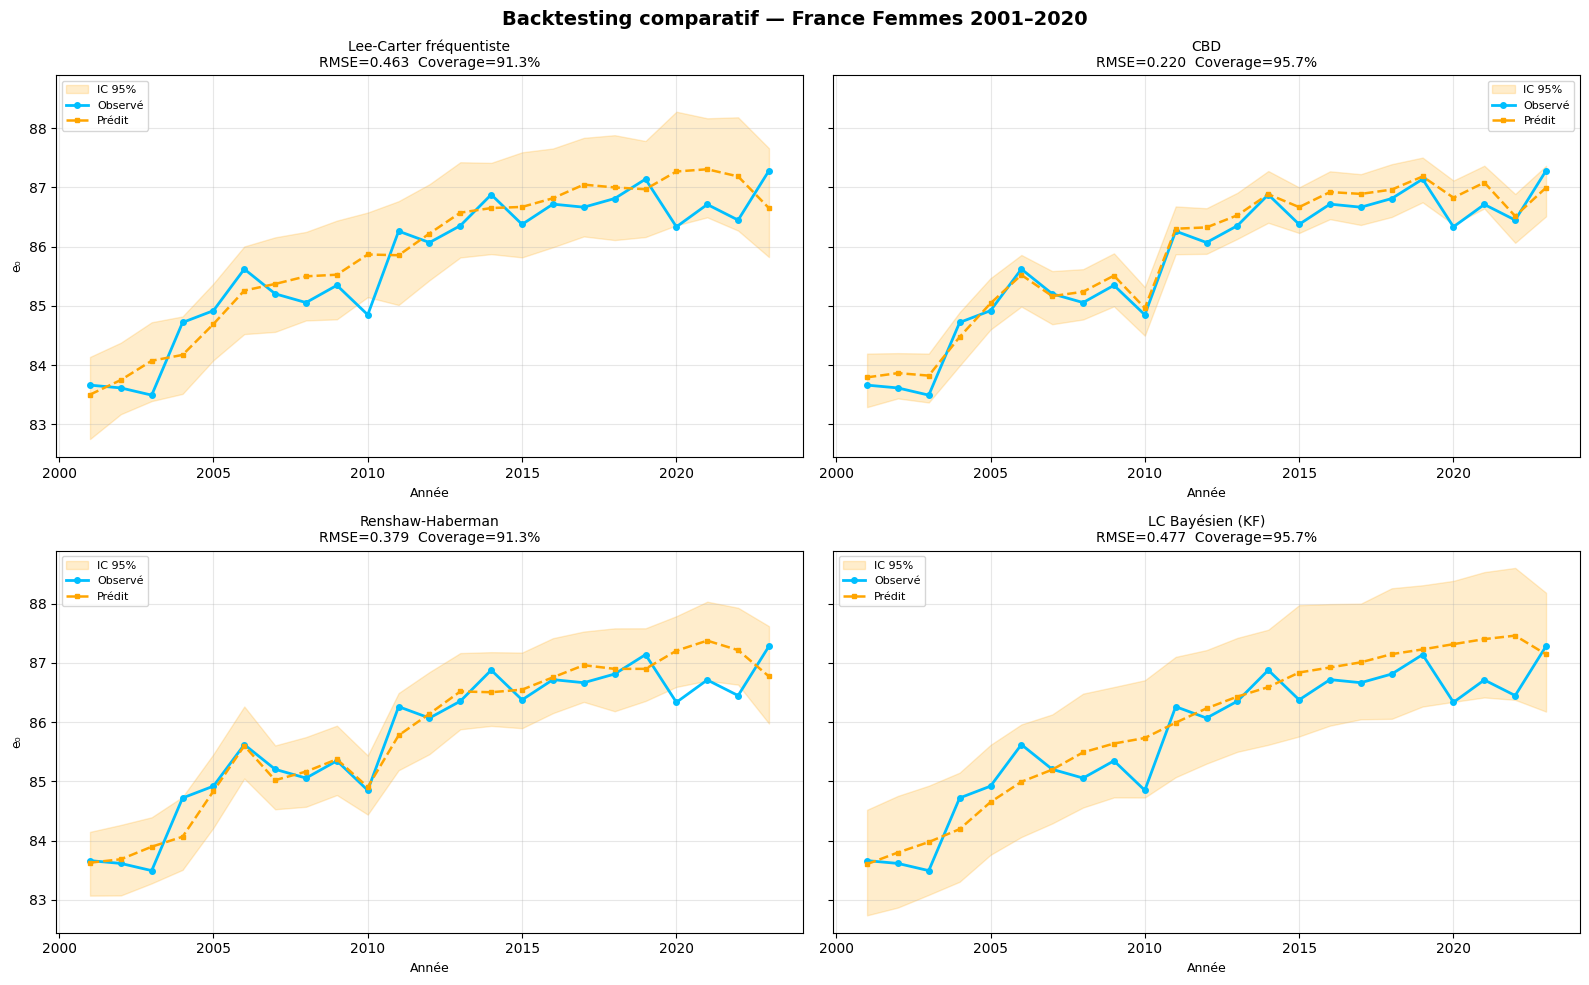

Tous les outputs sauvegardés dans outputs/


In [23]:
# ── Plot 4 modèles ────────────────────────────────────────────────────────────
panels = [
    ('Lee-Carter fréquentiste', res_lc['e0_obs'],  res_lc['e0_pred'],  res_lc['e0_lower'],  res_lc['e0_upper'],  res_lc['rmse'],  res_lc['coverage']),
    ('CBD',                     e0_obs_cbd,          e0_pred_cbd,         e0_lower_cbd,         e0_upper_cbd,         rmse_cbd,         coverage_cbd),
    ('Renshaw-Haberman',        res_rh['e0_obs'],  res_rh['e0_pred'],  res_rh['e0_lower'],  res_rh['e0_upper'],  res_rh['rmse'],  res_rh['coverage']),
    ('LC Bayésien (KF)',        res_bay['e0_obs'], res_bay['e0_pred'], res_bay['e0_lower'], res_bay['e0_upper'], res_bay['rmse'], res_bay['coverage']),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
fig.suptitle('Backtesting comparatif — France Femmes 2001–2020', fontsize=14, fontweight='bold')

for idx, (title, obs, pred, lo, hi, rmse, cov) in enumerate(panels):
    row, col = divmod(idx, 2)
    a = axes[row][col]
    a.fill_between(years_test, lo, hi, alpha=0.2, color='orange', label='IC 95%')
    a.plot(years_test, obs,  'o-',  color='#00BFFF', lw=2,   markersize=4, label='Observé')
    a.plot(years_test, pred, 's--', color='orange',  lw=1.8, markersize=3, label='Prédit')
    a.set_title(f'{title}\nRMSE={rmse:.3f}  Coverage={cov:.1%}', fontsize=10)
    a.set_xlabel('Année', fontsize=9)
    if col == 0: a.set_ylabel('e₀', fontsize=9)
    a.legend(fontsize=8); a.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/comparaison_finale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tous les outputs sauvegardés dans outputs/')